In [1]:
import pandas as pd

In [26]:
data = pd.read_csv('../data/chembl_cache/CHEMBL1827/CHEMBL1147608_CHEMBL762825.csv')

In [40]:
from rdkit import Chem
from rdkit.Chem import Draw

mols = [Chem.MolFromSmiles(x) for x in data['canonical_smiles']]

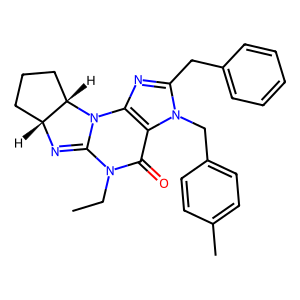

In [41]:
Draw.MolToImage(mols[0])

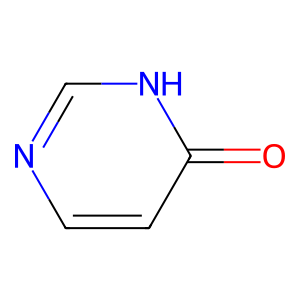

In [42]:
query = Chem.MolFromSmiles('O=C1C=CN=CN1')
Draw.MolToImage(query)

In [43]:
for mol in mols:
    if mol.HasSubstructMatch(query):
        print(Chem.MolToSmiles(mol))

CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12


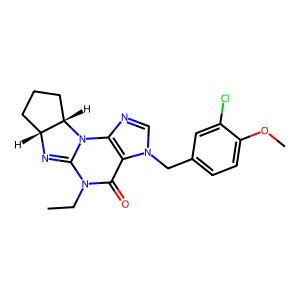

In [50]:
Draw.MolToImage(mol)

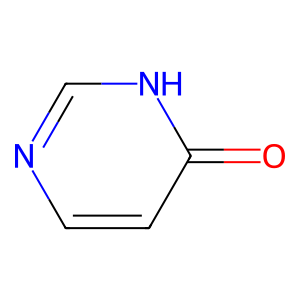

In [53]:
Draw.MolToImage(query)

In [55]:
# 2. Adjust the query to ignore bond types
params = Chem.AdjustQueryParameters()
params.makeBondsGeneric = True
params.makeAtomsGeneric = False  # Keep atom types (e.g., C vs N) specific

# Create the adjusted query
generic_query = Chem.AdjustQueryProperties(query, params)

# 3. Perform the match
is_match = mol.HasSubstructMatch(generic_query)
is_match

False

In [48]:
is_match

False

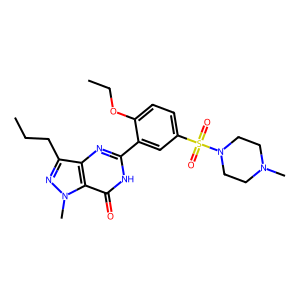

In [45]:
Draw.MolToImage(Chem.MolFromSmiles('CCCc1nn(C)c2c(=O)[nH]c(-c3cc(S(=O)(=O)N4CCN(C)CC4)ccc3OCC)nc12'))

In [ ]:
from fcgmb import FCGMBOracle

benchmarks = FCGMBOracle.list_benchmarks()
print(benchmarks)

['CHEMBL205_1YDA_CHEMBL2331308', 'CHEMBL2346486_6ORR_CHEMBL4414609', 'CHEMBL2971_7Q7L_CHEMBL5046242', 'CHEMBL3313835_7KCC_CHEMBL4834423', 'CHEMBL3313835_7KCE_CHEMBL4834423', 'CHEMBL3313835_7KCF_CHEMBL4834423', 'CHEMBL3313835_7KDA_CHEMBL4834423', 'CHEMBL3313835_7KDB_CHEMBL4834423', 'CHEMBL3820_4ISF_CHEMBL2346600', 'CHEMBL4482_5XVA_CHEMBL4028914', 'CHEMBL4482_5XVF_CHEMBL4028914', 'CHEMBL4630_2R0U_CHEMBL1140535']


In [1]:
from fcgmb import FCGMBOracle

# Initialize a benchmark
oracle = FCGMBOracle("CHEMBL205_1YDA_CHEMBL2331308", budget=5000)

# Get initial compounds for the generative model
initial_compounds = oracle.get_initial_compounds()

[FCGMB] Initialized benchmark: CHEMBL205_1YDA_CHEMBL2331308
[FCGMB] Scratch directory: /work/users/s/h/shuhang/benchmark/notebooks/.fcgmb
[FCGMB] Loading cached ChEMBL data from CHEMBL205_1YDA_CHEMBL2331308_chembl.csv
[FCGMB] Prepared 2 initial compounds (threshold pchembl_value <= 6.55)


In [2]:
oracle.score(['CCO', 'CCN'])

[FCGMB] Grid not found. Preparing receptor and protein-ligand grids for 1YDA...
   Falling back to direct RCSB download (mmCIF)...


PDBDownloadError: Failed to download PDB structure 1YDA: 502 Server Error: Bad Gateway for url: https://files.rcsb.org/download/1YDA.cif

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('../variance_runs/run_1/run_summary.csv')
df[df['pdb_id'].isin(['5XVA', '2R0U', '7KCF'])]

,config_file,target_id,pdb_id,doc_id,fragment_smiles,status,error_message,n_compounds_total,n_compounds_standardized,n_compounds_matched_2d,...,success_rate_rmsd,workflow_key,best_any_n_points,best_any_pearson,best_any_spearman,best_any_r2,rmsd_n_points,rmsd_pearson,rmsd_spearman,rmsd_r2
5,configs/CHEMBL3313835_7KCF_CHEMBL4834423.yaml,CHEMBL3313835,7KCF,CHEMBL4834423,O=C1C=CNC2=CC=NN12,SUCCESS,NaN,0,0,44,...,100.00,CHEMBL3313835_7KCF_CHEMBL4834423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,configs/CHEMBL4482_5XVA_CHEMBL4028914.yaml,CHEMBL4482,5XVA,CHEMBL4028914,NC1=NC=NC2=CC=CC=C21,SUCCESS,NaN,0,0,39,...,97.44,CHEMBL4482_5XVA_CHEMBL4028914,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,configs/CHEMBL4630_2R0U_CHEMBL1140535.yaml,CHEMBL4630,2R0U,CHEMBL1140535,O=C1NC=CC2=C1C1=C(C=CC=C1)C=C2,SUCCESS,NaN,0,0,44,...,95.45,CHEMBL4630_2R0U_CHEMBL1140535,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
